# Random Forest Classification

This notebook trains the Random Forest classifier for the binary stock-direction task. It mirrors the structure and assumptions used in the RF Continuous notebook to ensure consistency across both Random Forest models.

- `cleaned_dataset.csv` is the single source of truth for all models.
- The positive class is defined as `Stock_Return > 0` (label `1`).
- Training uses feature years `2014–2017`, testing uses `2018`.
- The same 201 shared numeric features used by the other models are retained.
- No feature standardisation is applied, as tree-based models are invariant to monotonic scaling.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
RANDOM_STATE = 42
DATA_PATH = 'cleaned_dataset.csv'

## 1. Load Data and Define Train/Test Split

Load the cleaned dataset, define the binary target, and split into training and test sets using the same time-aware logic as the RF regression notebook.

In [2]:
df = pd.read_csv(DATA_PATH)

# Remove identifiers, labels, and time markers from the feature matrix.
excluded_columns = {'Ticker', 'Sector', 'Stock_Return', 'Class', 'Year', 'Return_Direction'}
feature_columns = [col for col in df.columns if col not in excluded_columns]

# Binary target: 1 if the next-year return is positive, 0 otherwise.
y_direction = (df['Stock_Return'] > 0).astype(int)
if 'Return_Direction' in df.columns:
    assert (y_direction == df['Return_Direction']).all(), 'Return_Direction does not match Stock_Return > 0.'

# Time-aware split: train on 2014-2017 features, test on 2018 features.
train_mask = df['Year'].between(2014, 2017)
test_mask = df['Year'] == 2018

X_train = df.loc[train_mask, feature_columns].copy()
X_test = df.loc[test_mask, feature_columns].copy()
y_train = y_direction.loc[train_mask].copy()
y_test = y_direction.loc[test_mask].copy()
train_years = df.loc[train_mask, 'Year'].reset_index(drop=True)

print(f'Total observations: {df.shape[0]:,}')
print(f'Number of features used: {len(feature_columns)}')
print(f'Training rows (feature years 2014-2017): {len(X_train):,}')
print(f'Test rows (feature year 2018): {len(X_test):,}')
print(f'Missing values in selected features: {df[feature_columns].isna().sum().sum():,}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test positive rate: {y_test.mean():.3f}')

Total observations: 22,031
Number of features used: 201
Training rows (feature years 2014-2017): 17,641
Test rows (feature year 2018): 4,390
Missing values in selected features: 0
Train positive rate: 0.513
Test positive rate: 0.692


## 2. Expanding-Window Cross-Validation Splits

Build the same three expanding-window folds used for all model tuning in this project. This preserves temporal ordering and prevents future data from leaking into validation scores.

In [3]:
def make_expanding_year_splits(year_series: pd.Series):
    unique_years = sorted(year_series.unique())
    splits = []

    for index in range(1, len(unique_years)):
        train_year_subset = unique_years[:index]
        validation_year = unique_years[index]

        train_idx = np.where(year_series.isin(train_year_subset))[0]
        validation_idx = np.where(year_series == validation_year)[0]
        splits.append((train_idx, validation_idx))

    return splits


cv_splits = make_expanding_year_splits(train_years)
[(len(train_idx), len(val_idx)) for train_idx, val_idx in cv_splits]


[(3787, 4114), (7901, 4783), (12684, 4957)]

## 3. Hyperparameter Tuning

Tune the Random Forest classifier using the same hyperparameter grid as the RF regression model (Table III in the report). The scoring metric is macro F1, which gives equal weight to both classes.

In [4]:
# Same hyperparameter grid as the RF regression model (Table III in the report).
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_grid,
    cv=cv_splits,
    scoring='f1_macro',
    refit=False,
    verbose=1,
)
grid_search.fit(X_train, y_train)

# Display top 10 configurations.
cv_results = pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score')
display_cols = [
    'param_n_estimators', 'param_max_depth', 'param_min_samples_split',
    'mean_test_score', 'std_test_score', 'rank_test_score',
]
cv_top = cv_results[display_cols].head(10).copy()
cv_top = cv_top.rename(columns={'mean_test_score': 'cv_macro_f1', 'std_test_score': 'cv_macro_f1_std'})
print('Top 10 configurations by CV macro F1:')
display(cv_top)

best_params = grid_search.best_params_.copy()
print(f'\nBest configuration: {best_params}')
print(f'Best CV macro F1: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Top 10 configurations by CV macro F1:


,param_n_estimators,param_max_depth,param_min_samples_split,cv_macro_f1,cv_macro_f1_std,rank_test_score
3,300,5,5,0.510022,0.068481,1
5,300,5,10,0.509125,0.067728,2
2,100,5,5,0.508698,0.071342,3
4,100,5,10,0.507895,0.068429,4
1,300,5,2,0.507809,0.067297,5
0,100,5,2,0.506562,0.068050,6
9,300,10,5,0.502530,0.063507,7
11,300,10,10,0.499958,0.063844,8
10,100,10,10,0.499009,0.061982,9
7,300,10,2,0.498969,0.066339,10



Best configuration: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
Best CV macro F1: 0.5100


## 4. Fit Final Model and Evaluate on Test Set

Train the classifier with the best parameters on all training data and evaluate on the held-out 2018 feature-year test set. All metrics are macro-averaged for the report table.

In [5]:
# Train the final Random Forest classifier using the best parameters from grid search.
best_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params,
)
best_rf.fit(X_train, y_train)

# Generate predictions and predicted probabilities for the held-out test set.
rf_pred = best_rf.predict(X_test)
rf_prob_positive = best_rf.predict_proba(X_test)[:, 1]

# Compute all metrics needed for the report table (macro-averaged).
rf_results = pd.Series({
    'accuracy': accuracy_score(y_test, rf_pred),
    'roc_auc': roc_auc_score(y_test, rf_prob_positive),
    'precision_macro': precision_score(y_test, rf_pred, average='macro', zero_division=0),
    'recall_macro': recall_score(y_test, rf_pred, average='macro', zero_division=0),
    'f1_macro': f1_score(y_test, rf_pred, average='macro', zero_division=0),
}, name='Random Forest')

print('Best hyperparameters:')
print(best_params)
print()
print(rf_results.round(4))

Best hyperparameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}

accuracy           0.6825
roc_auc            0.7225
precision_macro    0.6435
recall_macro       0.6578
f1_macro           0.6471
Name: Random Forest, dtype: float64


## 5. Baseline Comparison

Compare the Random Forest against majority-class and stratified-random baselines to verify the model adds genuine predictive value.

In [6]:
baseline_models = {
    'Majority Class': DummyClassifier(strategy='most_frequent'),
    'Stratified Random': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
}

baseline_rows = []
for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    baseline_pred = model.predict(X_test)
    baseline_prob = model.predict_proba(X_test)[:, 1]

    baseline_rows.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, baseline_pred),
        'roc_auc': roc_auc_score(y_test, baseline_prob),
        'precision_macro': precision_score(y_test, baseline_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, baseline_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, baseline_pred, average='macro', zero_division=0),
    })

results_table = pd.concat([
    pd.DataFrame(baseline_rows).set_index('model'),
    rf_results.to_frame().T,
]).round(4)

results_table

,accuracy,roc_auc,precision_macro,recall_macro,f1_macro
Majority Class,0.6918,0.5000,0.3459,0.5000,0.4089
Stratified Random,0.4973,0.4914,0.4926,0.4914,0.4755
Random Forest,0.6825,0.7225,0.6435,0.6578,0.6471


## 6. Classification Report, Confusion Matrix, and ROC Curve

Detailed per-class metrics, the confusion matrix heatmap, and the ROC curve for the final Random Forest classifier.

In [7]:
print(classification_report(y_test, rf_pred, target_names=["Negative return", "Positive return"], zero_division=0))

cm = confusion_matrix(y_test, rf_pred)
cm_df = pd.DataFrame(cm, index=["Actual negative", "Actual positive"], columns=["Predicted negative", "Predicted positive"])
cm_df


                 precision    recall  f1-score   support

Negative return       0.49      0.59      0.54      1353
Positive return       0.80      0.72      0.76      3037

       accuracy                           0.68      4390
      macro avg       0.64      0.66      0.65      4390
   weighted avg       0.70      0.68      0.69      4390



,Predicted negative,Predicted positive
Actual negative,803,550
Actual positive,844,2193


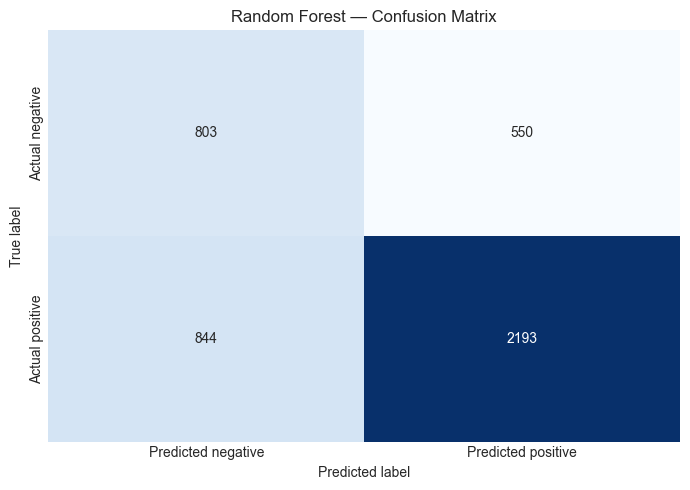

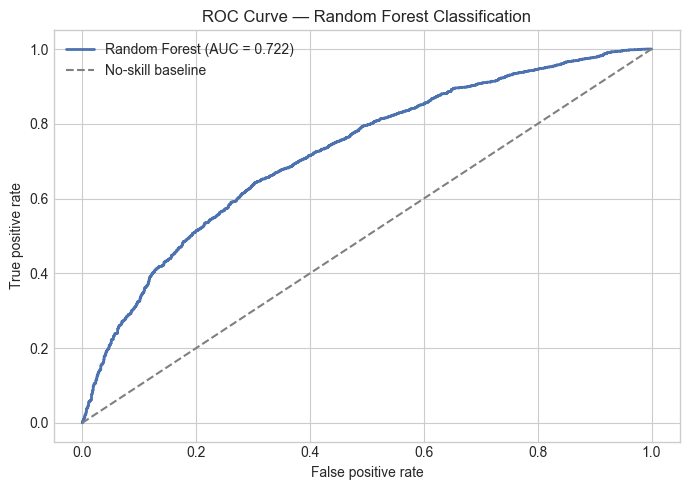

In [8]:
# Confusion matrix heatmap.
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Random Forest — Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.show()

# ROC curve.
fpr, tpr, _ = roc_curve(y_test, rf_prob_positive)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob_positive):.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='No-skill baseline')
ax.set_title('ROC Curve — Random Forest Classification')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Feature Importance

Impurity-based feature importance from the trained classifier. This highlights which accounting variables are most useful for predicting return direction and can be compared with the regression feature importances.

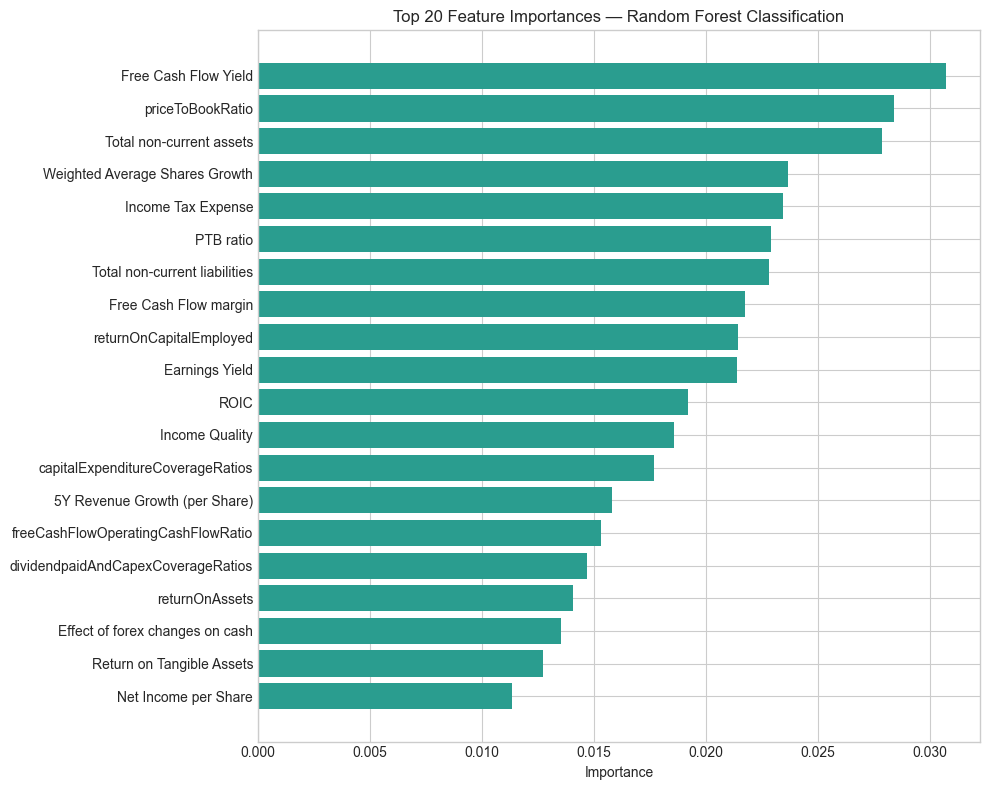

,importance
Free Cash Flow Yield,0.030713
priceToBookRatio,0.028390
Total non-current assets,0.027881
Weighted Average Shares Growth,0.023667
Income Tax Expense,0.023460
PTB ratio,0.022910
Total non-current liabilities,0.022803
Free Cash Flow margin,0.021753
returnOnCapitalEmployed,0.021437
Earnings Yield,0.021372


In [9]:
# Impurity-based feature importance from the trained forest.
feature_importances = pd.Series(
    best_rf.feature_importances_,
    index=feature_columns,
).sort_values(ascending=False)

top_features = feature_importances.head(20).sort_values()

plt.figure(figsize=(10, 8))
plt.barh(top_features.index, top_features.values, color='#2a9d8f')
plt.title('Top 20 Feature Importances — Random Forest Classification')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_features.to_frame('importance').sort_values('importance', ascending=False)

## 8. Notes for the Report

- The positive class is `1 = positive future return`; the reported probability is the probability of an upward return.
- The train/test split matches the report: train on feature years `2014–2017`, test on `2018` (realised returns `2019`).
- The feature matrix excludes `Ticker`, `Sector`, `Stock_Return`, `Class`, `Year`, and `Return_Direction`, leaving the shared 201 numeric features.
- The hyperparameter grid matches the RF regression model (Table III): `n_estimators [100, 300]`, `max_depth [5, 10, None]`, `min_samples_split [2, 5, 10]`.
- `class_weight='balanced'` is applied to handle the class imbalance (54.9% positive in training).
- No `StandardScaler` is applied, as Random Forest is invariant to monotonic feature transformations.
- All metrics reported are macro-averaged to give equal weight to both classes.